In [57]:


# ==================== CELLULE 1: IMPORTS ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')


In [74]:

# Configuration de l'affichage
#plt.style.use('ggplot')
#sns.set_palette("husl")

print("✓ Bibliothèques importées avec succès!")


# ==================== CELLULE 2: CHARGEMENT DES DONNÉES ====================
# Charger le dataset
df = pd.read_csv('C:/Users/morel/Desktop/Resume1.csv')

print("=" * 60)
print("INFORMATIONS SUR LE DATASET")
print("=" * 60)
print(f"\nNombre total de CV : {len(df)}")
print(f"Colonnes disponibles : {list(df.columns)}")
print(f"\nPremières lignes :")
print(df.head())


✓ Bibliothèques importées avec succès!
INFORMATIONS SUR LE DATASET

Nombre total de CV : 2484
Colonnes disponibles : ['ID', 'Resume_str', 'Resume_html', 'Category']

Premières lignes :
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  


In [75]:



# Informations sur les colonnes
print("\n" + "=" * 60)
print("STRUCTURE DES DONNÉES")
print("=" * 60)
df.info()



STRUCTURE DES DONNÉES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [76]:
print("Total number of missing values")
print(30 * "-")
print(df.isna().sum())
print(30 * "-")
print("Total missing values are:", df.isna().sum().sum())
print(30 * "-")


Total number of missing values
------------------------------
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64
------------------------------
Total missing values are: 0
------------------------------


<Axes: >

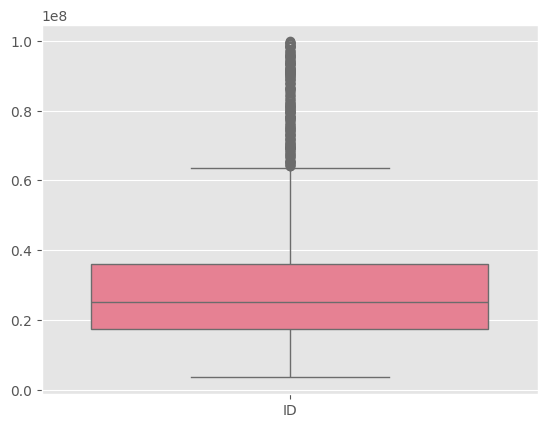

In [77]:
sns.boxplot(df)


In [78]:


# ==================== CELLULE 3: ANALYSE DES CATÉGORIES ====================
print("\n" + "=" * 60)
print("DISTRIBUTION DES CATÉGORIES")
print("=" * 60)

# Compter les catégories
category_counts = df['Category'].value_counts()
print(f"\nNombre de catégories uniques : {len(category_counts)}")
print(f"\nTop 10 catégories :")
print(category_counts.head(10))



DISTRIBUTION DES CATÉGORIES

Nombre de catégories uniques : 24

Top 10 catégories :
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
Name: count, dtype: int64


Text(0, 0.5, 'Catégorie')

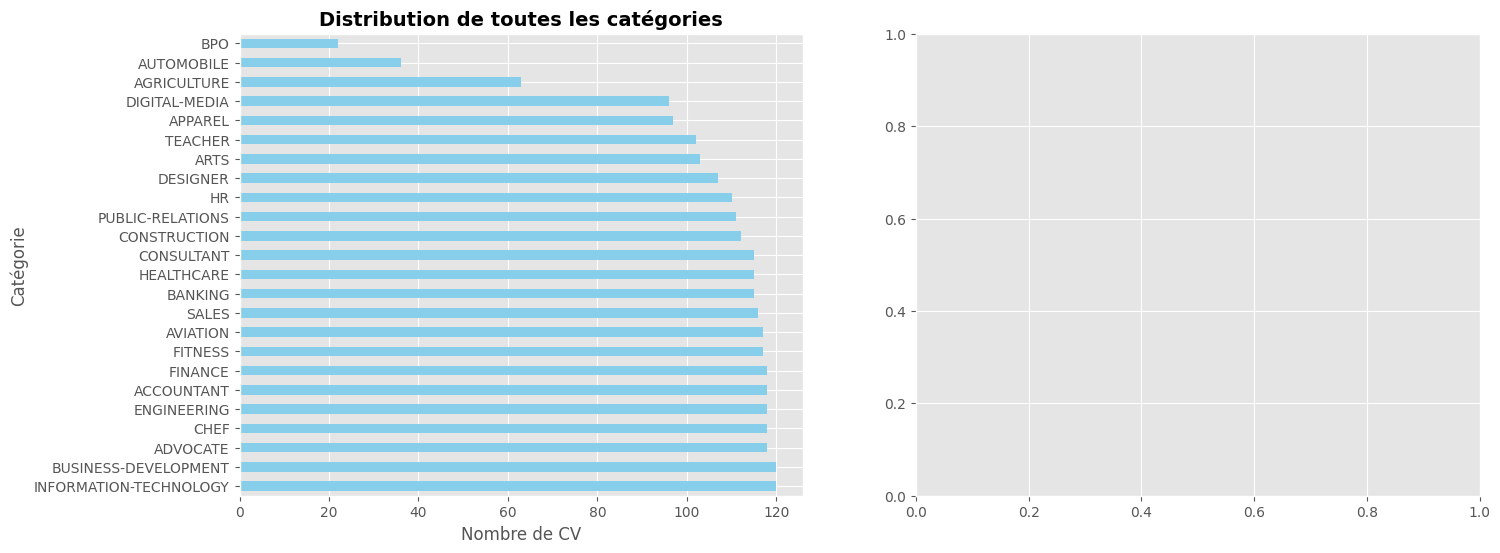

In [79]:

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1: Toutes les catégories
category_counts.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution de toutes les catégories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de CV')
axes[0].set_ylabel('Catégorie')


In [80]:

# Graphique 2: Top 15 catégories
category_counts.head(15).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Catégories', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Catégorie')
axes[1].set_ylabel('Nombre de CV')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>

In [81]:

# ==================== CELLULE 4: ANALYSE DES TEXTES ====================
print("\n" + "=" * 60)
print("ANALYSE DES TEXTES DES CV")
print("=" * 60)

# Longueur des CV
df['text_length'] = df['Resume_str'].astype(str).apply(len)
df['word_count'] = df['Resume_str'].astype(str).apply(lambda x: len(x.split()))

print(f"\nStatistiques de longueur des CV :")
print(f"Longueur moyenne : {df['text_length'].mean():.0f} caractères")
print(f"Longueur médiane : {df['text_length'].median():.0f} caractères")
print(f"Nombre moyen de mots : {df['word_count'].mean():.0f} mots")



ANALYSE DES TEXTES DES CV

Statistiques de longueur des CV :
Longueur moyenne : 6295 caractères
Longueur médiane : 5886 caractères
Nombre moyen de mots : 811 mots


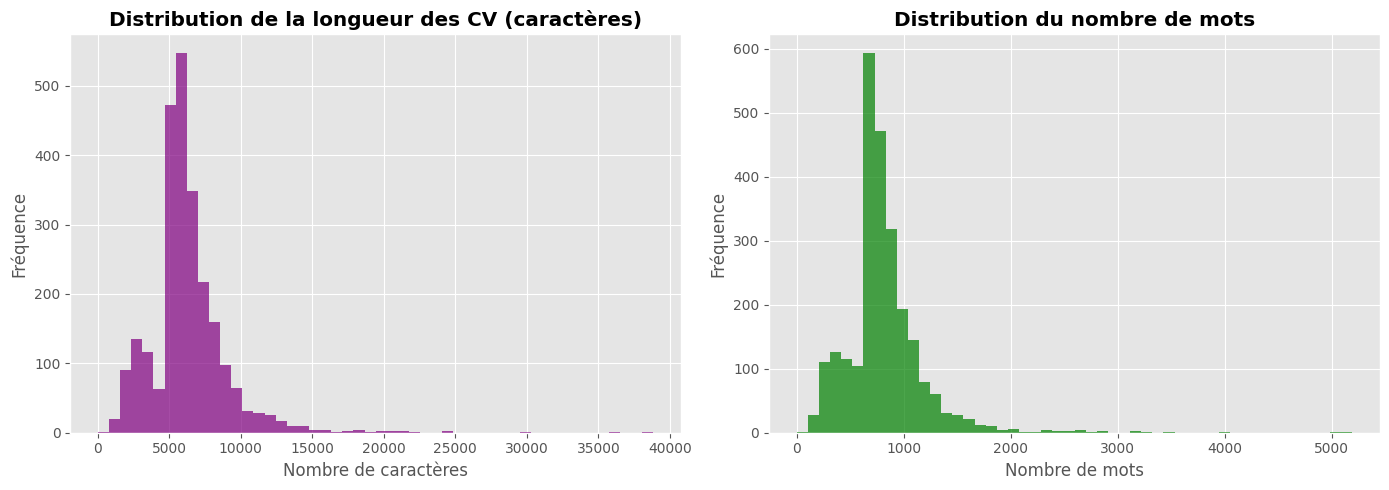

In [82]:

# Visualisation de la distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='purple', alpha=0.7)
axes[0].set_title('Distribution de la longueur des CV (caractères)', fontweight='bold')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')

axes[1].hist(df['word_count'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Distribution du nombre de mots', fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()


In [83]:


# ==================== CELLULE 5: NUAGE DE MOTS ====================
print("\n" + "=" * 60)
print("GÉNÉRATION DES NUAGES DE MOTS")
print("=" * 60)

# Fonction pour créer un nuage de mots
def create_wordcloud(text, title, category=None):
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.tight_layout(pad=0)
    plt.show()




GÉNÉRATION DES NUAGES DE MOTS


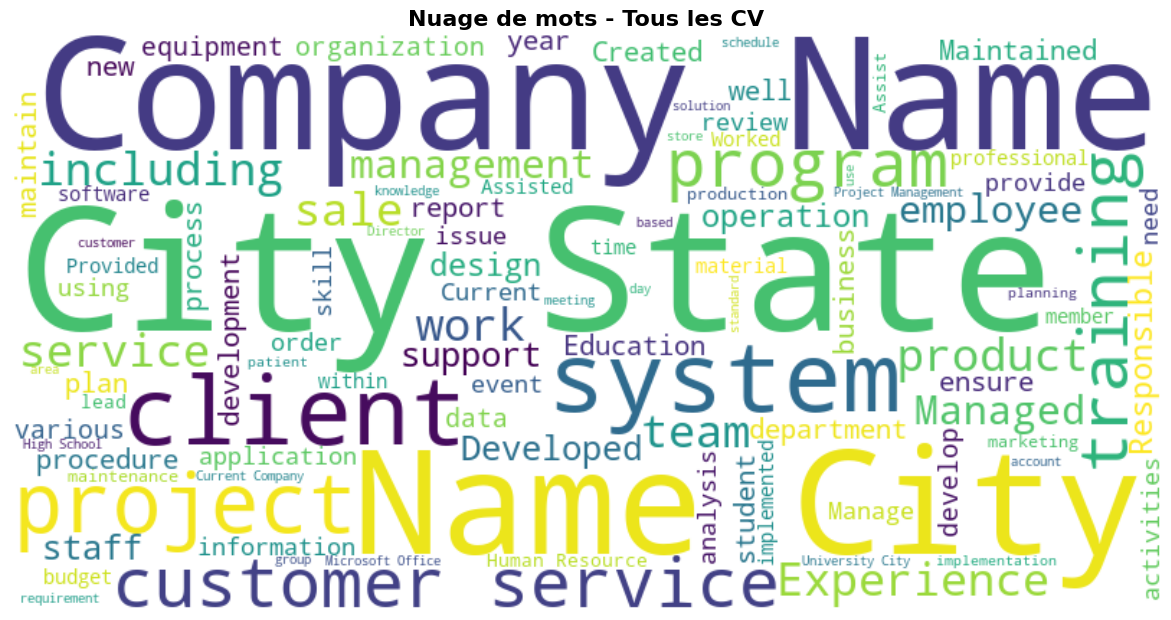

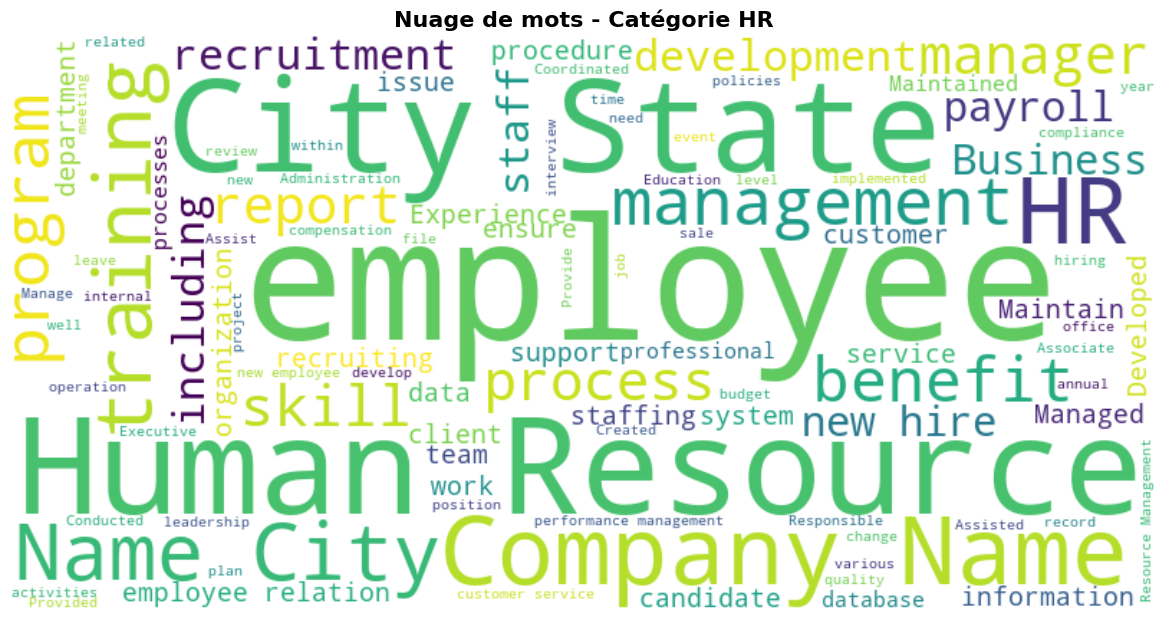

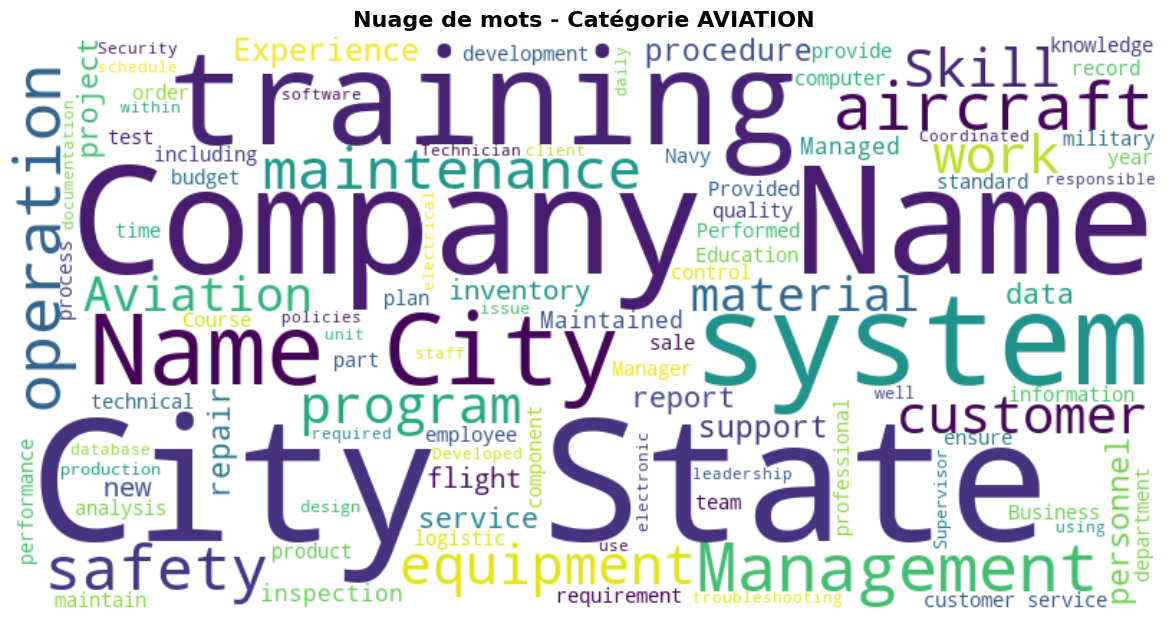


EXTRACTION DES COMPÉTENCES TECHNIQUES

Top 15 compétences les plus fréquentes :
ai                  : 2473 CV
management          : 2120 CV
excel               : 1616 CV
communication       : 1505 CV
leadership          : 1028 CV
powerpoint          :  499 CV
sql                 :  191 CV
java                :   98 CV
javascript          :   56 CV
python              :   40 CV
react               :   35 CV
node                :   26 CV
vue                 :   14 CV
machine learning    :   12 CV
angular             :    8 CV


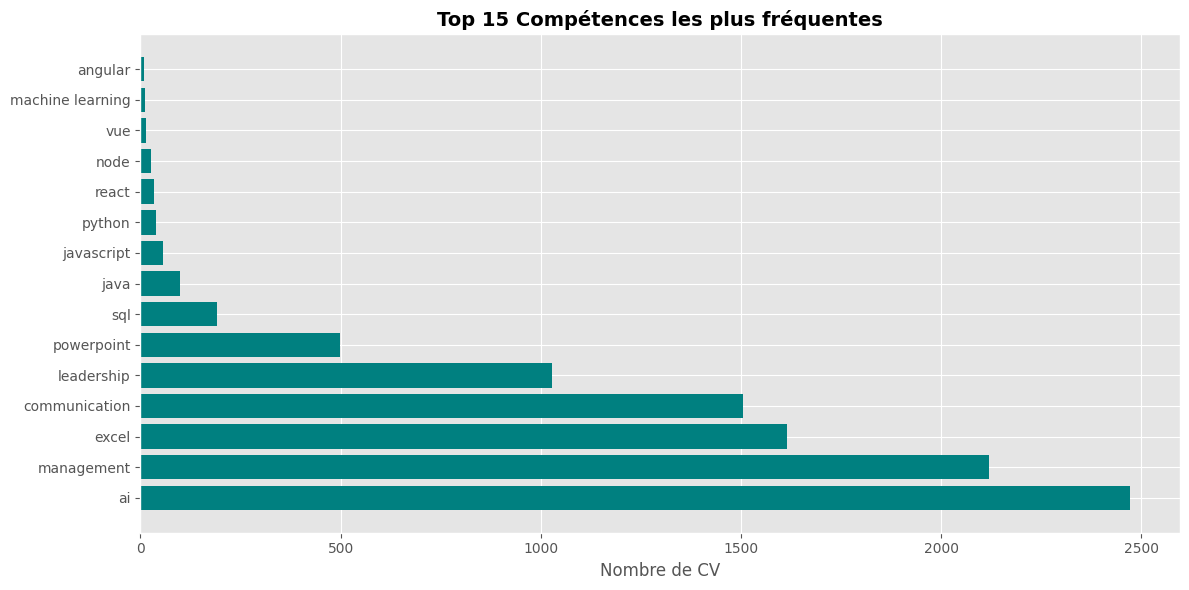


MACHINE LEARNING - PRÉPARATION DES DONNÉES
Données après nettoyage : 2483 CV
Catégories : 24

Vectorisation TF-IDF en cours...
Shape de la matrice TF-IDF : (2483, 1000)
Ensemble d'entraînement : 1986 CV
Ensemble de test : 497 CV

ENTRAÎNEMENT DE PLUSIEURS MODÈLES

--- Naive Bayes ---
Accuracy : 58.95%

--- Random Forest ---
Accuracy : 72.03%

--- Logistic Regression ---
Accuracy : 67.20%

--- SVM ---
Accuracy : 69.62%


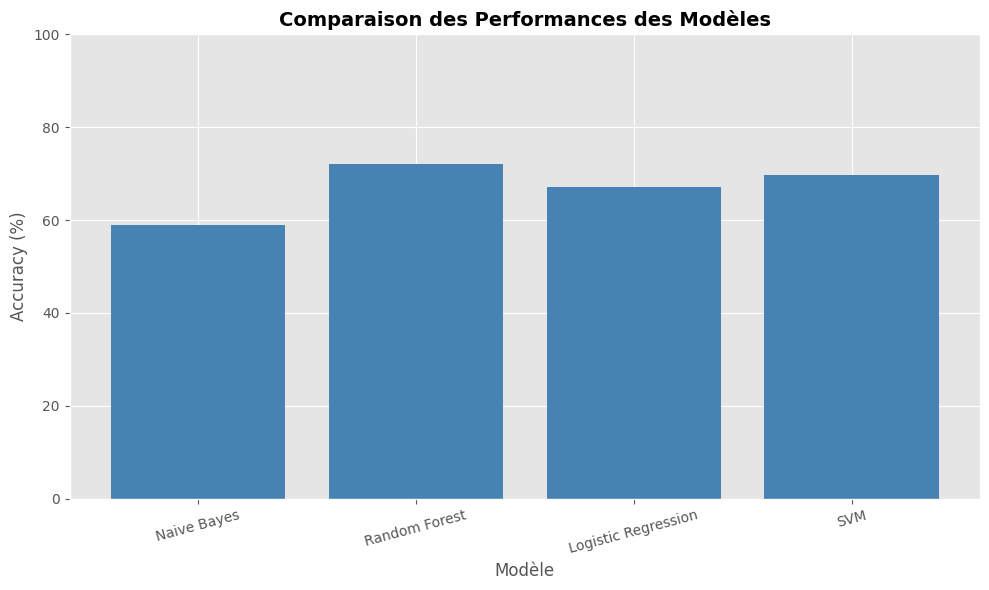

In [84]:
# Nuage de mots global
all_text = ' '.join(df['Resume_str'].astype(str))
create_wordcloud(all_text, 'Nuage de mots - Tous les CV')

# Nuage de mots pour HR
hr_text = ' '.join(df[df['Category'] == 'HR']['Resume_str'].astype(str))
create_wordcloud(hr_text, 'Nuage de mots - Catégorie HR')

# Nuage de mots pour AVIATION (si disponible)
if 'AVIATION' in df['Category'].values:
    aviation_text = ' '.join(df[df['Category'] == 'AVIATION']['Resume_str'].astype(str))
    create_wordcloud(aviation_text, 'Nuage de mots - Catégorie AVIATION')


# ==================== CELLULE 6: EXTRACTION DE COMPÉTENCES ====================
print("\n" + "=" * 60)
print("EXTRACTION DES COMPÉTENCES TECHNIQUES")
print("=" * 60)

# Liste de compétences à rechercher
skills_keywords = [
    'python', 'java', 'javascript', 'react', 'angular', 'vue',
    'node', 'sql', 'mongodb', 'docker', 'kubernetes',
    'machine learning', 'deep learning', 'ai', 'excel',
    'powerpoint', 'leadership', 'communication', 'management'
]

# Fonction pour extraire les compétences
def extract_skills(text):
    text_lower = str(text).lower()
    found_skills = [skill for skill in skills_keywords if skill in text_lower]
    return found_skills

# Appliquer l'extraction
df['extracted_skills'] = df['Resume_str'].apply(extract_skills)
df['skills_count'] = df['extracted_skills'].apply(len)

# Compter les compétences les plus fréquentes
from collections import Counter
all_skills = [skill for skills_list in df['extracted_skills'] for skill in skills_list]
skill_counts = Counter(all_skills)

print(f"\nTop 15 compétences les plus fréquentes :")
for skill, count in skill_counts.most_common(15):
    print(f"{skill:20s}: {count:4d} CV")

# Visualisation
top_skills = dict(skill_counts.most_common(15))
plt.figure(figsize=(12, 6))
plt.barh(list(top_skills.keys()), list(top_skills.values()), color='teal')
plt.xlabel('Nombre de CV')
plt.title('Top 15 Compétences les plus fréquentes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ==================== CELLULE 7: MACHINE LEARNING - PRÉPARATION ====================
print("\n" + "=" * 60)
print("MACHINE LEARNING - PRÉPARATION DES DONNÉES")
print("=" * 60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Nettoyer le texte
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_text'] = df['Resume_str'].apply(clean_text)

# Supprimer les lignes vides
df_clean = df[df['cleaned_text'] != ''].copy()

print(f"Données après nettoyage : {len(df_clean)} CV")
print(f"Catégories : {df_clean['Category'].nunique()}")

# Encoder les catégories
le = LabelEncoder()
df_clean['category_encoded'] = le.fit_transform(df_clean['Category'])

# Vectorisation TF-IDF
print("\nVectorisation TF-IDF en cours...")
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X = tfidf.fit_transform(df_clean['cleaned_text'])
y = df_clean['category_encoded']

print(f"Shape de la matrice TF-IDF : {X.shape}")

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Ensemble d'entraînement : {X_train.shape[0]} CV")
print(f"Ensemble de test : {X_test.shape[0]} CV")


# ==================== CELLULE 8: ENTRAÎNEMENT DES MODÈLES ====================
print("\n" + "=" * 60)
print("ENTRAÎNEMENT DE PLUSIEURS MODÈLES")
print("=" * 60)

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Dictionnaire des modèles
models = {
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': LinearSVC(random_state=42, max_iter=1000)
}

# Entraîner et évaluer chaque modèle
results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy : {accuracy*100:.2f}%")

# Comparaison visuelle
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), [acc*100 for acc in results.values()], color='steelblue')
plt.xlabel('Modèle')
plt.ylabel('Accuracy (%)')
plt.title('Comparaison des Performances des Modèles', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()




🏆 Meilleur modèle : Random Forest avec 72.03% d'accuracy

MATRICE DE CONFUSION DU MEILLEUR MODÈLE


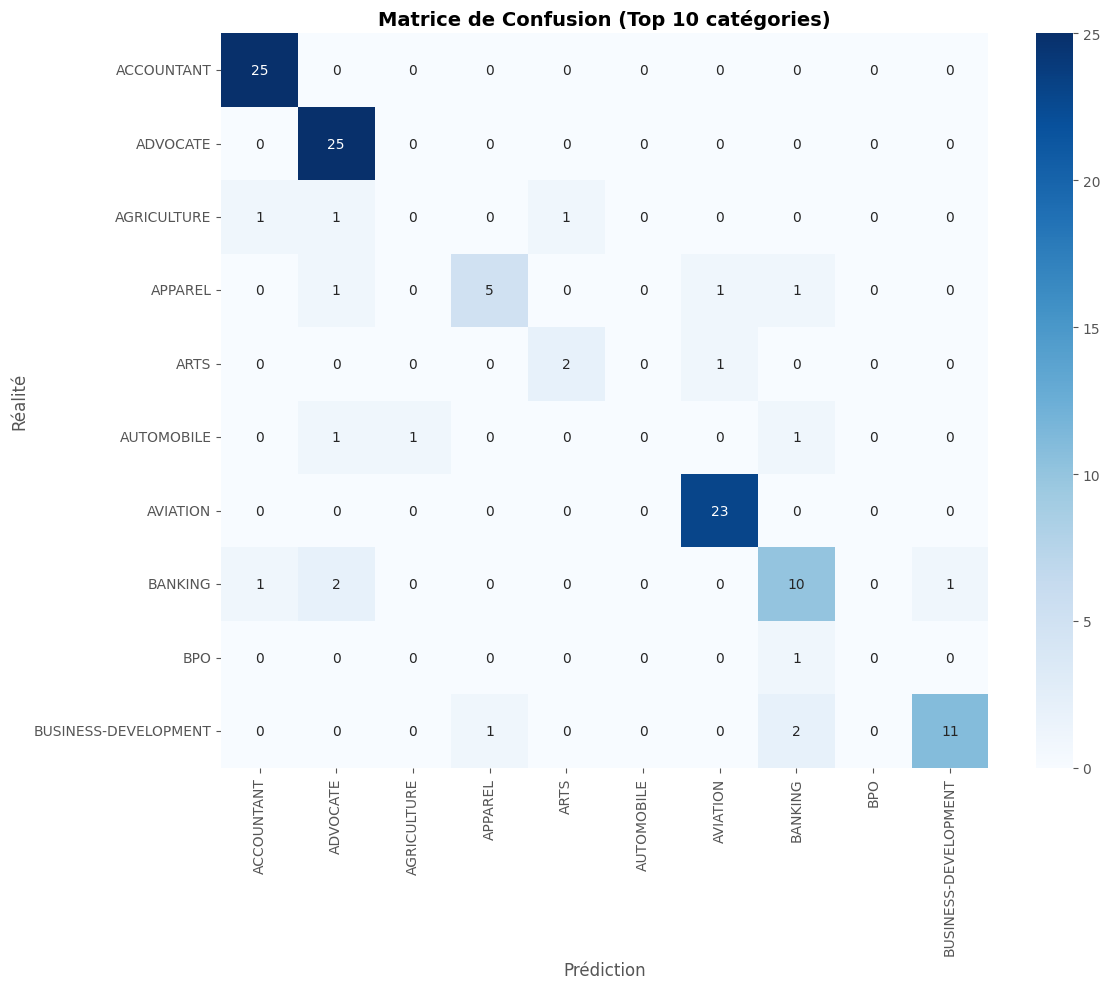


TEST DE PRÉDICTION SUR UN NOUVEAU CV
Catégorie réelle : HR
Catégorie prédite : HR

Top 3 prédictions :
  HR                            : 52.00%
  BUSINESS-DEVELOPMENT          : 6.00%
  FITNESS                       : 5.00%

SAUVEGARDE DU MODÈLE
✓ Modèle sauvegardé : cv_classifier_model.pkl
✓ Vectorizer sauvegardé : tfidf_vectorizer.pkl
✓ Label Encoder sauvegardé : label_encoder.pkl

RAPPORT FINAL D'ANALYSE

📊 RÉSUMÉ DE L'ANALYSE DU DATASET CV

1. DONNÉES
   - Total de CV analysés : 2484
   - Catégories uniques : 24
   - Longueur moyenne : 6295 caractères
   - Nombre moyen de mots : 811 mots

2. CATÉGORIES LES PLUS REPRÉSENTÉES
   1. INFORMATION-TECHNOLOGY: 120 CV (4.8%)
   2. BUSINESS-DEVELOPMENT: 120 CV (4.8%)
   3. ADVOCATE: 118 CV (4.8%)
   4. CHEF: 118 CV (4.8%)
   5. ENGINEERING: 118 CV (4.8%)

3. COMPÉTENCES LES PLUS DEMANDÉES
   1. ai: 2473 CV
   2. management: 2120 CV
   3. excel: 1616 CV
   4. communication: 1505 CV
   5. leadership: 1028 CV

4. PERFORMANCE DES MODÈLES ML
  

In [85]:
# Meilleur modèle
best_model_name = max(results, key=results.get)
print(f"\n🏆 Meilleur modèle : {best_model_name} avec {results[best_model_name]*100:.2f}% d'accuracy")


# ==================== CELLULE 9: MATRICE DE CONFUSION ====================
print("\n" + "=" * 60)
print("MATRICE DE CONFUSION DU MEILLEUR MODÈLE")
print("=" * 60)

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Utiliser le meilleur modèle (Random Forest généralement)
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Afficher pour les 10 premières catégories seulement (pour lisibilité)
n_categories = min(10, len(le.classes_))
cm_subset = cm[:n_categories, :n_categories]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_[:n_categories],
            yticklabels=le.classes_[:n_categories])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title(f'Matrice de Confusion (Top {n_categories} catégories)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ==================== CELLULE 10: TEST DE PRÉDICTION ====================
print("\n" + "=" * 60)
print("TEST DE PRÉDICTION SUR UN NOUVEAU CV")
print("=" * 60)

def predict_cv_category(cv_text, model, vectorizer, label_encoder):
    """Prédit la catégorie d'un nouveau CV"""
    # Nettoyer
    cleaned = clean_text(cv_text)
    
    # Vectoriser
    vectorized = vectorizer.transform([cleaned])
    
    # Prédire
    prediction = model.predict(vectorized)[0]
    probas = model.predict_proba(vectorized)[0]
    
    # Décoder
    category = label_encoder.inverse_transform([prediction])[0]
    
    # Top 3 catégories
    top_indices = probas.argsort()[-3:][::-1]
    top_categories = [
        (label_encoder.inverse_transform([i])[0], probas[i]) 
        for i in top_indices
    ]
    
    return category, top_categories

# Test avec un CV du dataset
test_cv = df_clean.iloc[100]['Resume_str']
actual_category = df_clean.iloc[100]['Category']

predicted, top_3 = predict_cv_category(test_cv, best_model, tfidf, le)

print(f"Catégorie réelle : {actual_category}")
print(f"Catégorie prédite : {predicted}")
print(f"\nTop 3 prédictions :")
for cat, prob in top_3:
    print(f"  {cat:30s}: {prob*100:.2f}%")


# ==================== CELLULE 11: SAUVEGARDE DU MODÈLE ====================
print("\n" + "=" * 60)
print("SAUVEGARDE DU MODÈLE")
print("=" * 60)

import pickle

# Sauvegarder le modèle
with open('cv_classifier_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Sauvegarder le vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Sauvegarder le label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✓ Modèle sauvegardé : cv_classifier_model.pkl")
print("✓ Vectorizer sauvegardé : tfidf_vectorizer.pkl")
print("✓ Label Encoder sauvegardé : label_encoder.pkl")


# ==================== CELLULE 12: RAPPORT FINAL ====================
print("\n" + "=" * 60)
print("RAPPORT FINAL D'ANALYSE")
print("=" * 60)

report = f"""
📊 RÉSUMÉ DE L'ANALYSE DU DATASET CV
{'='*60}

1. DONNÉES
   - Total de CV analysés : {len(df)}
   - Catégories uniques : {df['Category'].nunique()}
   - Longueur moyenne : {df['text_length'].mean():.0f} caractères
   - Nombre moyen de mots : {df['word_count'].mean():.0f} mots

2. CATÉGORIES LES PLUS REPRÉSENTÉES
"""

for i, (cat, count) in enumerate(category_counts.head(5).items(), 1):
    report += f"   {i}. {cat}: {count} CV ({count/len(df)*100:.1f}%)\n"

report += f"""
3. COMPÉTENCES LES PLUS DEMANDÉES
"""

for i, (skill, count) in enumerate(skill_counts.most_common(5), 1):
    report += f"   {i}. {skill}: {count} CV\n"

report += f"""
4. PERFORMANCE DES MODÈLES ML
"""

for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    report += f"   - {name}: {acc*100:.2f}%\n"

report += f"""
5. RECOMMANDATIONS
   ✓ Utiliser le modèle {best_model_name} pour la classification
   ✓ Combiner TF-IDF avec des features manuelles pour améliorer
   ✓ Ajouter du preprocessing avancé (lemmatisation, etc.)
   ✓ Considérer des modèles de deep learning (BERT, etc.)

{'='*60}
"""

print(report)

# Sauvegarder le rapport
with open('cv_analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✓ Rapport sauvegardé : cv_analysis_report.txt")
